# MATH 4340 / COSC 4340: Numerical Methods for Differential Equations
# Notebook 15: Nonlinear PDEs

### Professor: Dane Taylor
### Date: Spring 2024


In [5]:
%pylab inline
import timeit
from scipy import sparse
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve
from scipy import optimize

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


## 1. Recall Root Finding with Newton's Method

In [6]:
#define functions for different i
def fi(i,z):
    if i==0: 
        return 2*z[0] - z[1]
    elif i==1: # right boundary
        return -5*z[1] - z[0]    
    
#stack functions into a list
def F(z):
    F = []
    for i in range(len(z)): # spatial index
        def f_i(z): return fi(i,z)
        F.append(f_i(z))  
    return F

In [7]:
# First try build in root finder in SciPy

In [8]:
z0 = array([10.9,1.1])
sol = optimize.root(F, z0,  method='hybr')
sol.x

array([0., 0.])

In [9]:
F(sol.x)

[0.0, -0.0]

In [10]:
# Now Newton's method

In [11]:
def DF(z): # Jacobian matrix for F
    J = array([[2,-1],[-5,-1]])
    return J

def newton_step(z):
    J = DF(z)
    #uuu =  z - inv(J)@F(z) # best to not invert J
    y = linalg.solve(J,  J@z - F(z))
    #y = spsolve(J,  J@z - F(z))

    return y

#Implement Newtons method iterations
def newton_iterations(newton_step):
    yy = ones(2)
    change = 1
    tol = 10**(-14)
    while change>tol:
        print(yy)
        y_temp = newton_step(yy)
        change = norm(y_temp-yy)
        yy =y_temp
    return yy

In [12]:
u= random.rand(2)
J = DF(u)
sol = newton_iterations(newton_step)
sol

[1. 1.]
[-0. -0.]


array([-0., -0.])

## 2. Fisher's Equation Example

In [13]:
D = .05
h = .01
n = int(1/h)

k = .01
N = int(3/k)

xi = linspace(0,1,n+1)
tj = linspace(0,3,N+1)

In [14]:
# initital and boundary conditions
def l(t):return 0*t # homogeneous dirichlet
def r(t):return 0*t # homogeneous dirichlet

In [15]:
sigma = D*k/h**2

def fi(i,z,past_ui):
    n = len(z)-1
    if i==0: # left boundary
        #return z[0] - l_bound
        return (-3*z[0] + 4*z[1] -1*z[2] )/(2*h)
    elif i==n: # right boundary
        #return z[-1] - r_bound
        return ( -3*z[-1] + 4*z[-2] -1*z[-3] )/(2*h)
    else:
        return (1+2*sigma - k + k*z[i])*z[i] -sigma*(z[i+1]+z[i-1]) - past_ui
    
    
def F(z):
#    l_bound = l(tj[j])
#    r_bound = r(tj[j])
    F = []
    for i in range(n+1): # spatial index
        past_ui = uu[j,i] # past value at time tj
        def f_i(z): 
            return fi(i,z,past_ui)
        F.append(f_i(z))  
    return F

In [16]:
uu = zeros((N+1,n+1))
u0 = sin(pi*xi)
uu[0] = u0.copy()

for j in range(N):
    sol = optimize.root(F, uu[j],  method='hybr')
    uu[j+1] = sol.x
    

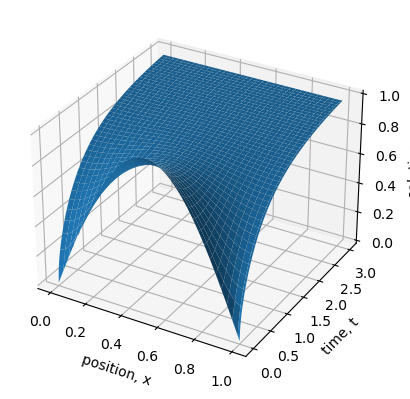

In [17]:
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111, projection='3d')
xx, tt = np.meshgrid(xi, tj)
ax.plot_surface(xx, tt, uu)

ax.set_xlabel('position, x')
ax.set_ylabel('time, t')
ax.set_zlabel('solution, u')
plt.tight_layout();

In [18]:
def DF(z): # Jacobian matrix for F
    J = zeros((n+1,n+1))
    J[0,:3] = array([-3,4,-1])/(2*h)
    J[n,n-2:] = array([-1,4,-3])/(2*h)
    J[1,0] = -sigma 
    J[n-1,n] = -sigma
        
    beta = 1 + 2*sigma - k(1-  2*z[1:-1]) # diag position

    temp  = diag(-sigma*ones(n-2),-1) + diag(-sigma*ones(n-2),1) + diag(beta)
    J[1:-1,1:-1] = temp
    return  csr_matrix(J)

def newton_step(z):
    J = DF(z)
    uuu = spsolve(J,  J@z - F(z))
    #uuu =  z - inv(J)@F(z)
    return uuu

#Implement Newtons method iterations
def newton_iterations(u_start,newton_step):
    yy =  u_start.copy()
    change = 1
    tol = 10**(-13)
    while change>tol:    
        y_temp = newton_step(yy)
        change = norm(y_temp-yy)
        yy =y_temp
    return yy

In [19]:
uu_newton = zeros((N+1,n+1))
uu_newton[0] = u0.copy()

for j in range(N):  
    u_start=uu_newton[j]
    uu_newton[j+1] = newton_iterations(u_start,newton_step)

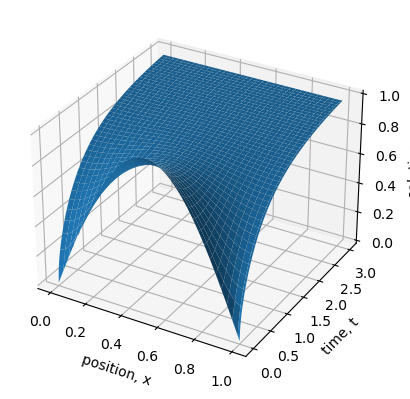

In [20]:
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111, projection='3d')
xx, tt = np.meshgrid(xi, tj)
ax.plot_surface(xx, tt, uu_newton)

ax.set_xlabel('position, x')
ax.set_ylabel('time, t')
ax.set_zlabel('solution, u')
plt.tight_layout();

### How long does the code take if you don't use a sparse matrix?